<a href="https://colab.research.google.com/github/me-khushboo-malik/HHS_children_allien/blob/main/khushboo_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load and Inspect Dataset**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")

# Display first 5 rows
print(df.head())

# Basic info
print(df.info())

# Summary statistics
print(df.describe())

                Date  Children apprehended and placed in CBP custody*  \
0  December 21, 2025                                              6.0   
1  December 18, 2025                                             11.0   
2  December 17, 2025                                              7.0   
3  December 16, 2025                                              8.0   
4  December 15, 2025                                             11.0   

   Children in CBP custody  Children transferred out of CBP custody  \
0                     18.0                                     11.0   
1                     50.0                                      6.0   
2                     31.0                                     11.0   
3                     54.0                                     15.0   
4                     42.0                                      9.0   

  Children in HHS Care  Children discharged from HHS Care  
0                2,484                               14.0  
1             

In [ ]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Remove commas and convert to numeric
df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(',', '').astype(float)

# Check missing values
print(df.isnull().sum())

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


**Find Total, Mean, Max, Min**

In [ ]:
print("Total Children in CBP custody:", df['Children in CBP custody'].sum())
print("Average Children in HHS Care:", df['Children in HHS Care'].mean())
print("Maximum Children apprehended:", df['Children apprehended and placed in CBP custody*'].max())
print("Minimum Children discharged:", df['Children discharged from HHS Care'].min())

Total Children in CBP custody: 123476.0
Average Children in HHS Care: 6061.275
Maximum Children apprehended: 333.0
Minimum Children discharged: 0.0


**Time Series Analysis**

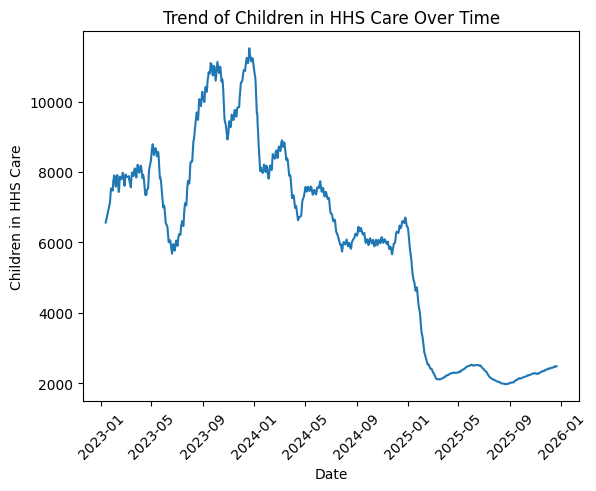

In [ ]:
# Sort by date
df = df.sort_values('Date')

# Plot trend
import matplotlib.pyplot as plt

plt.plot(df['Date'], df['Children in HHS Care'])
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("Trend of Children in HHS Care Over Time")
plt.xticks(rotation=45)
plt.show()

**Correlation Analysis**

In [ ]:
# Correlation matrix
correlation = df.corr(numeric_only=True)
print(correlation)

                                                 Children apprehended and placed in CBP custody*  \
Children apprehended and placed in CBP custody*                                         1.000000   
Children in CBP custody                                                                 0.950604   
Children transferred out of CBP custody                                                 0.887896   
Children in HHS Care                                                                    0.691312   
Children discharged from HHS Care                                                       0.627755   

                                                 Children in CBP custody  \
Children apprehended and placed in CBP custody*                 0.950604   
Children in CBP custody                                         1.000000   
Children transferred out of CBP custody                         0.925039   
Children in HHS Care                                            0.663662   
Children discharged

**Highest and Lowest Records**

In [ ]:
# Highest CBP custody
print(df.loc[df['Children in CBP custody'].idxmax()])

# Lowest CBP custody
print(df.loc[df['Children in CBP custody'].idxmin()])

Date                                               2024-02-04 00:00:00
Children apprehended and placed in CBP custody*                  253.0
Children in CBP custody                                          531.0
Children transferred out of CBP custody                          248.0
Children in HHS Care                                            7813.0
Children discharged from HHS Care                                342.0
Name: 466, dtype: object
Date                                               2025-02-25 00:00:00
Children apprehended and placed in CBP custody*                   11.0
Children in CBP custody                                            7.0
Children transferred out of CBP custody                            7.0
Children in HHS Care                                            2413.0
Children discharged from HHS Care                                 23.0
Name: 200, dtype: object


**Grouping (Monthly Analysis)**

In [ ]:
# Extract month
df['Month'] = df['Date'].dt.month

# Group by month
monthly_avg = df.groupby('Month')['Children in HHS Care'].mean()
print(monthly_avg)

Month
1.0     6990.076923
2.0     6335.741379
3.0     6042.193548
4.0     5629.924242
5.0     6241.606557
6.0     5528.586207
7.0     5100.539683
8.0     5780.762712
9.0     6124.269841
10.0    6219.671875
11.0    6053.327586
12.0    6932.035714
Name: Children in HHS Care, dtype: float64


**Visualization (Bar Chart)**

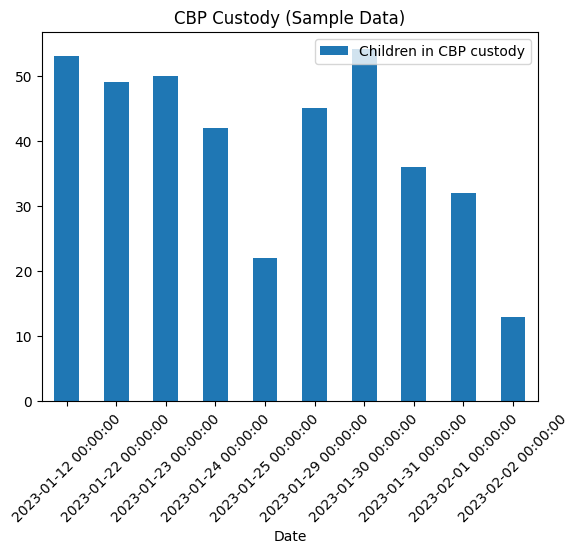

In [ ]:
df.head(10).plot(x='Date', y='Children in CBP custody', kind='bar')
plt.title("CBP Custody (Sample Data)")
plt.xticks(rotation=45)
plt.show()

**Detect Trends (Increase/Decrease)**

In [ ]:
df['Change'] = df['Children in HHS Care'].diff()

print(df[['Date', 'Children in HHS Care', 'Change']])

           Date  Children in HHS Care  Change
719  2023-01-12                6566.0     NaN
718  2023-01-22                7122.0   556.0
717  2023-01-23                7280.0   158.0
716  2023-01-24                7433.0   153.0
715  2023-01-25                7538.0   105.0
...         ...                   ...     ...
1165        NaT                   NaN     NaN
1166        NaT                   NaN     NaN
1167        NaT                   NaN     NaN
1168        NaT                   NaN     NaN
1169        NaT                   NaN     NaN

[1170 rows x 3 columns]


**Export Cleaned Data**

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)